In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
df = pd.read_csv(r"C:\Users\hp\Downloads\data_customer.csv")

df.head()

,Customer_ID,Age,Annual_Income,Credit_Limit,Balance,Purchases,Payment_Ratio,Late_Payments,Utilization,Risk_Level
0,1,59,1406155,359962,253061,494160,0.39,3,0.70,Medium Risk
1,2,49,849053,850533,723591,275109,0.96,4,0.85,Medium Risk
2,3,35,1382001,267431,269680,100334,0.67,1,1.01,High Risk
3,4,63,474143,761708,361073,90025,0.60,2,0.47,Low Risk
4,5,28,1835998,268226,248143,652110,0.42,3,0.93,High Risk


In [5]:
df.shape

(50000, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    50000 non-null  int64  
 1   Age            50000 non-null  int64  
 2   Annual_Income  50000 non-null  int64  
 3   Credit_Limit   50000 non-null  int64  
 4   Balance        50000 non-null  int64  
 5   Purchases      50000 non-null  int64  
 6   Payment_Ratio  50000 non-null  float64
 7   Late_Payments  50000 non-null  int64  
 8   Utilization    50000 non-null  float64
 9   Risk_Level     50000 non-null  object 
dtypes: float64(2), int64(7), object(1)
memory usage: 3.8+ MB


In [8]:
df['Annual_Income'].mean()

np.float64(1101342.79826)

In [9]:
df['Credit_Limit'].mean()

np.float64(525460.62868)

In [11]:
df.isnull().sum()

Customer_ID      0
Age              0
Annual_Income    0
Credit_Limit     0
Balance          0
Purchases        0
Payment_Ratio    0
Late_Payments    0
Utilization      0
Risk_Level       0
dtype: int64

In [12]:
df['Risk_Level'].value_counts()

Risk_Level
High Risk      28096
Low Risk       13641
Medium Risk     8263
Name: count, dtype: int64

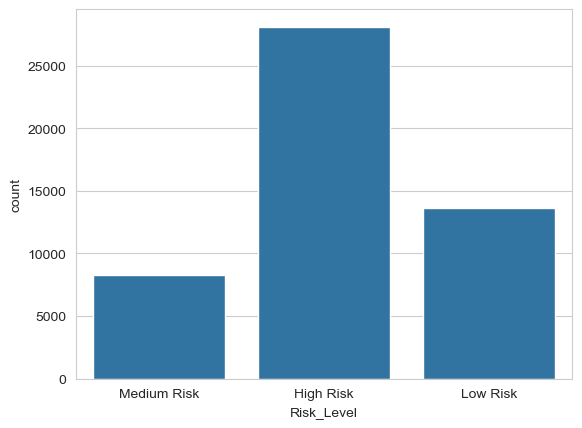

In [13]:
sns.countplot(x='Risk_Level', data=df)

plt.show()

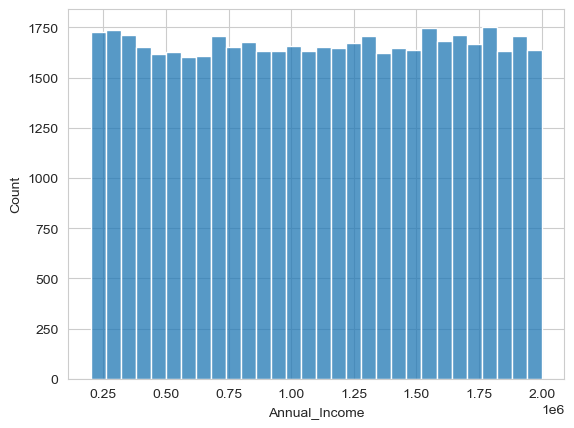

In [14]:
sns.histplot(df['Annual_Income'], bins=30)

plt.show()

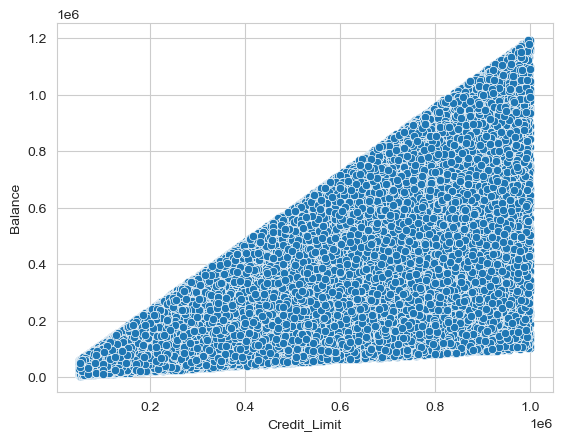

In [15]:
sns.scatterplot(x="Credit_Limit", y="Balance", data=df)

plt.show()

In [16]:
#do high risk have late payment 
df.groupby('Risk_Level')['Late_Payments'].mean()

Risk_Level
High Risk      6.061788
Low Risk       2.504142
Medium Risk    2.515309
Name: Late_Payments, dtype: float64

In [17]:
#which customer use more credit

df.sort_values(by="Utilization", ascending=False).head()

,Customer_ID,Age,Annual_Income,Credit_Limit,Balance,Purchases,Payment_Ratio,Late_Payments,Utilization,Risk_Level
17717,17718,31,1646357,851785,1019883,375498,0.82,2,1.2,High Risk
31929,31930,52,764213,455550,544714,91904,0.91,3,1.2,High Risk
24785,24786,53,948071,77788,93167,170070,0.88,5,1.2,High Risk
7438,7439,68,924776,826342,989138,334588,0.38,5,1.2,High Risk
186,187,61,1606700,367533,440295,301408,0.67,1,1.2,High Risk


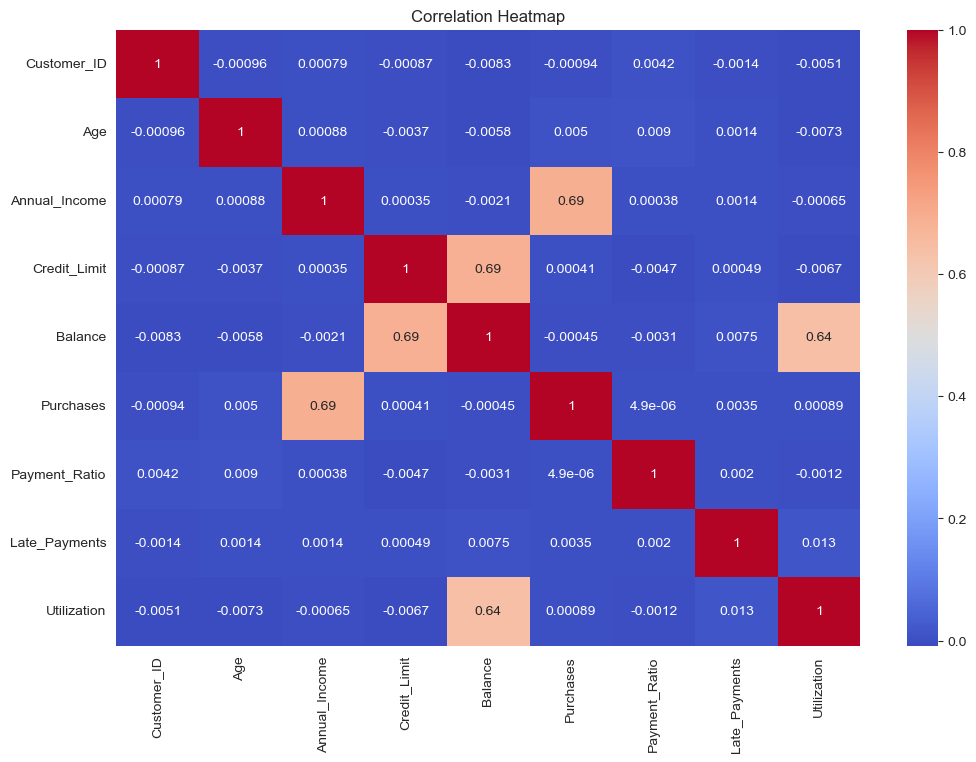

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [20]:
df.groupby('Risk_Level')['Annual_Income'].mean()

Risk_Level
High Risk      1.102341e+06
Low Risk       1.099672e+06
Medium Risk    1.100709e+06
Name: Annual_Income, dtype: float64

In [21]:
df.groupby('Risk_Level')['Credit_Limit'].mean()

Risk_Level
High Risk      524999.456506
Low Risk       525256.642402
Medium Risk    527365.465932
Name: Credit_Limit, dtype: float64

In [22]:
df[df['Risk_Level']=="High Risk"].head(10)

,Customer_ID,Age,Annual_Income,Credit_Limit,Balance,Purchases,Payment_Ratio,Late_Payments,Utilization,Risk_Level
2,3,35,1382001,267431,269680,100334,0.67,1,1.01,High Risk
4,5,28,1835998,268226,248143,652110,0.42,3,0.93,High Risk
8,9,43,245248,324072,155138,32725,0.33,6,0.48,High Risk
10,11,31,1104083,506636,586269,100669,0.62,7,1.16,High Risk
11,12,44,458945,348613,329964,73442,0.84,8,0.95,High Risk
12,13,56,524393,891338,113147,174450,0.65,9,0.13,High Risk
13,14,60,921194,714268,668426,322751,0.34,1,0.94,High Risk
14,15,44,1416532,903825,935814,97731,0.59,4,1.04,High Risk
15,16,23,1780511,167498,82398,431485,0.96,9,0.49,High Risk
17,18,22,941139,573515,324637,138263,0.97,6,0.57,High Risk


In [23]:
df[df['Risk_Level']=="High Risk"].shape[0]

28096

In [24]:
df[df['Risk_Level']=="High Risk"]['Balance'].mean()

np.float64(401741.7722807517)

In [25]:
df.groupby('Risk_Level')['Annual_Income'].mean()

Risk_Level
High Risk      1.102341e+06
Low Risk       1.099672e+06
Medium Risk    1.100709e+06
Name: Annual_Income, dtype: float64

<Axes: xlabel='Risk_Level', ylabel='count'>

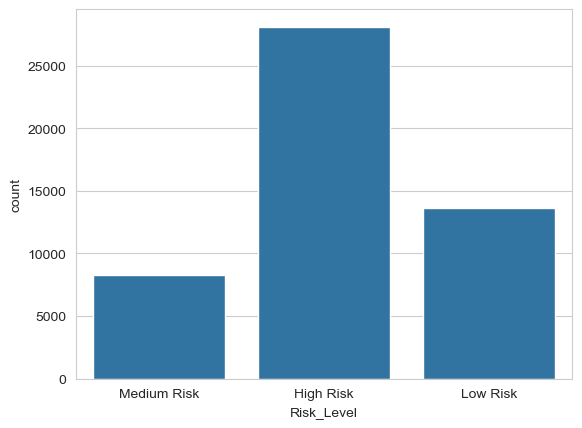

In [26]:
sns.countplot(x='Risk_Level', data=df)

<Axes: xlabel='Balance', ylabel='Count'>

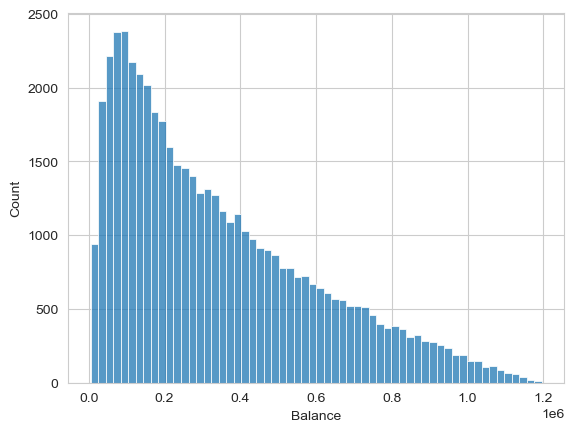

In [27]:
sns.histplot(df['Balance'])

<Axes: xlabel='Annual_Income', ylabel='Credit_Limit'>

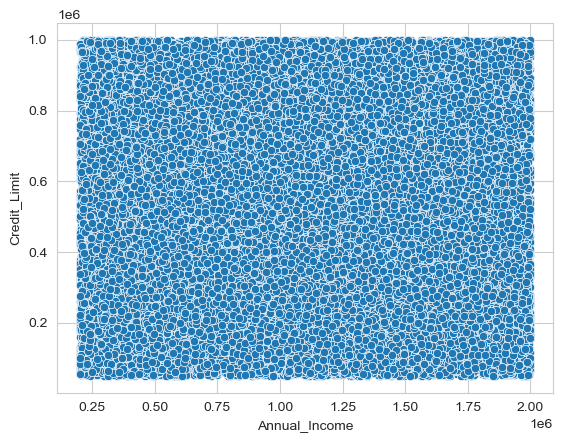

In [28]:
sns.scatterplot(x="Annual_Income", y="Credit_Limit", data=df)